<a href="https://colab.research.google.com/github/MeBiswas/k-means-clustering/blob/main/K-means%20Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Program to Implement K-Means clustering Algorithm.*

# *Step 1: Import necessary libraries*

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Wine.csv to Wine.csv


# *Step 2: Load the Wine dataset*

In [ ]:
df = pd.read_csv('Wine.csv')

**Display basic information about the dataset**

In [ ]:
print("Shape of the dataset:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nSummary Statistics:")
print(df.describe())

Shape of the dataset: (178, 14)

First 5 rows of the dataset:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  Customer_Se

# *Step 3: Data Preprocessing*

In [ ]:
if df.columns[0].lower() in ['class', 'target', 'customer_segment']:
    X = df.iloc[:, 1:].values  # excluding label column
else:
    X = df.values

# *Step 4: Correlation Matrix (EDA)*

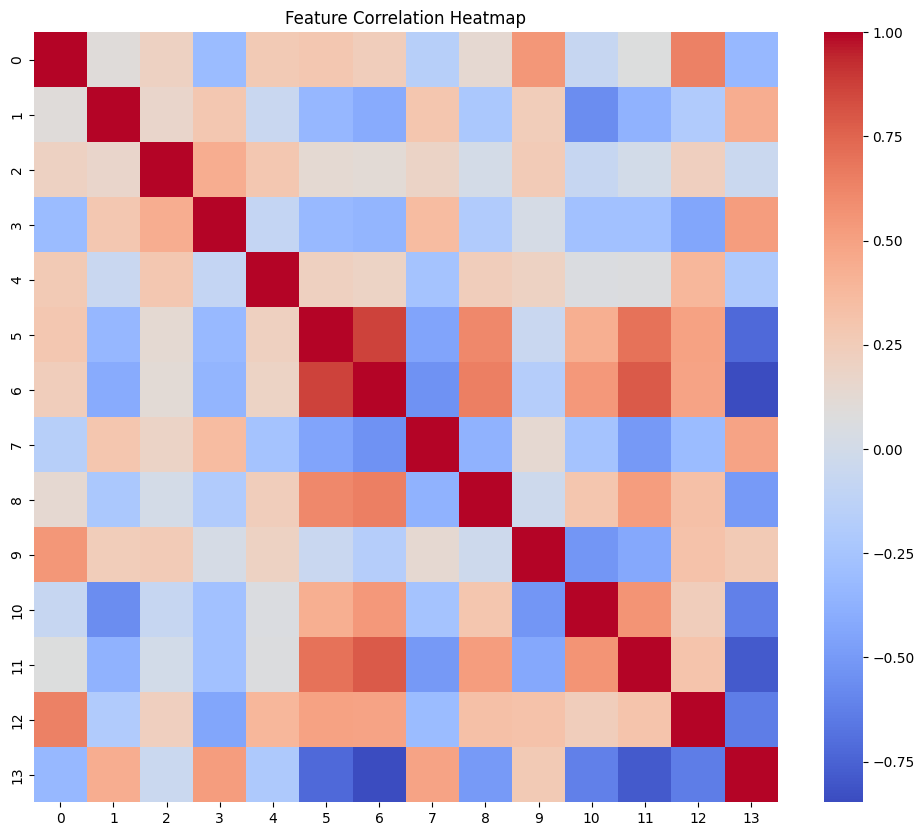

In [ ]:
plt.figure(figsize=(12, 10))
corr = pd.DataFrame(X).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# *Step 5: Standardize the features*

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# *Step 6: Find the optimal number of clusters using Elbow Method*

In [ ]:
wcss = []  # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

**Plot the Elbow graph**

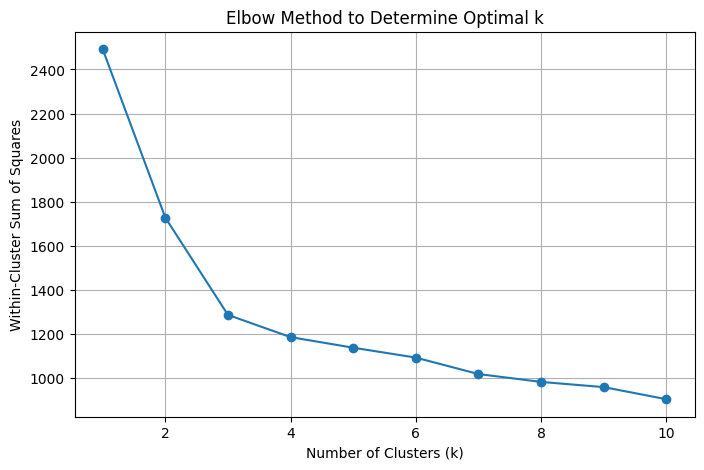

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares')
plt.grid(True)
plt.show()

# *Step 7: Apply K-Means Clustering*

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("\nCluster Centers (scaled feature space):")
print(centroids)

print("\nCluster Labels for each data point:")
print(labels)


Cluster Centers (scaled feature space):
[[-9.09328403e-01 -3.80707476e-01 -5.19747426e-01  1.37767008e-01
  -4.97451451e-01 -9.62003532e-02 -7.65223671e-04 -4.11471063e-03
   1.12388425e-02 -8.81229129e-01  4.32636626e-01  2.30777949e-01
  -7.63273163e-01  7.99603601e-02]
 [ 1.86543138e-01  9.04971453e-01  2.49210264e-01  5.83703484e-01
  -5.06353947e-02 -9.88556997e-01 -1.23619475e+00  7.16841717e-01
  -7.49607560e-01  9.88498285e-01 -1.19129878e+00 -1.30153966e+00
  -3.80044610e-01  1.34745816e+00]
 [ 8.35232085e-01 -3.03809683e-01  3.64706042e-01 -6.10191294e-01
   5.77586799e-01  8.85237363e-01  9.77819557e-01 -5.62089654e-01
   5.80286581e-01  1.71063479e-01  4.73983650e-01  7.79247107e-01
   1.12518529e+00 -1.15133539e+00]]

Cluster Labels for each data point:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0

# *Step 8: Visualize the Clusters (Using PCA for 2D visualization)*

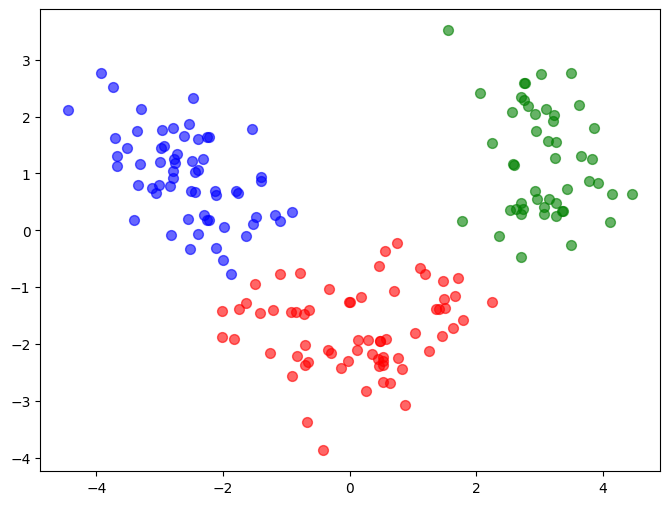

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i in range(len(X_pca)):
    plt.scatter(X_pca[i, 0], X_pca[i, 1], color=colors[labels[i]], s=50, alpha=0.6)

**Plot centroids**

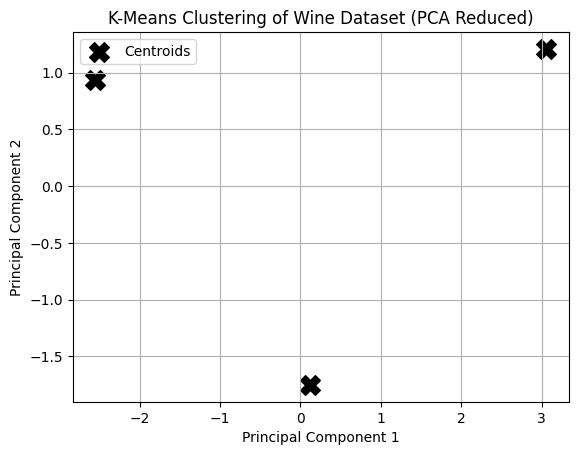

In [ ]:
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroids')

plt.title('K-Means Clustering of Wine Dataset (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# *Step 9: Analyze mean values of each cluster*

In [ ]:
df_clusters = pd.DataFrame(X, columns=df.columns[1:] if df.columns[0].lower() in ['class', 'target', 'customer_segment'] else df.columns)
df_clusters['Cluster'] = labels

# Calculate mean values of each feature for each cluster
cluster_means = df_clusters.groupby('Cluster').mean()

print("\nMean Values of Each Cluster:")
print(cluster_means)


Mean Values of Each Cluster:
           Alcohol  Malic_Acid       Ash  Ash_Alcanity   Magnesium  \
Cluster                                                              
0        12.264478    1.912239  2.224328     19.953731   92.656716   
1        13.151633    3.344490  2.434694     21.438776   99.020408   
2        13.676774    1.997903  2.466290     17.462903  107.967742   

         Total_Phenols  Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  \
Cluster                                                                     
0             2.235075    2.028507              0.361343         1.597313   
1             1.678163    0.797959              0.450816         1.163061   
2             2.847581    3.003226              0.292097         1.922097   

         Color_Intensity       Hue     OD280      Proline  Customer_Segment  
Cluster                                                                      
0               3.020896  1.056060  2.775075   507.208955          2.000000  